# Анализ лояльности пользователей Яндекс Афиши

Автор: Закиров Тимур Ильдарович

Дата: 19.10.2025

## Цели и задачи проекта
### Цель проекта
Провести исследовательский анализ данных о пользователях Яндекс Афиши, чтобы выявить факторы, влияющие на вероятность их возврата на платформу для совершения повторных заказов.
### Задачи проекта
**Шаг 1. Загрузка данных и первичное знакомство**

- Задача 1.1: Написать SQL-запрос и выгрузить данные из БД data-analyst-afisha в pandas DataFrame.

- Задача 1.2: Изучить общую информацию о данных (размер, типы, пропуски), оценить корректность выгрузки и сформулировать план предобработки.

**Шаг 2. Предобработка данных**

- Задача 2.1: Привести выручку к единой валюте (RUB), создав столбец revenue_rub.

- Задача 2.2:

Проверить и обработать пропущенные значения.

Преобразовать типы данных (дата/время, числовые).

Проверить и нормализовать категориальные признаки.

Выявить и обработать выбросы в ключевых числовых полях (revenue_rub, tickets_count).

**Шаг 3. Создание и анализ профиля пользователя**

- Задача 3.1: Построить агрегированные признаки для каждого пользователя:

Признаки первого заказа (устройство, регион, партнер, жанр).

Поведенческие метрики (общее число заказов, средняя выручка, среднее кол-во билетов, средний интервал между заказами).

Бинарные признаки на возврат (is_two, is_five).

- Задача 3.2: Провести дескриптивный анализ профилей пользователей:

Рассчитать ключевые статистики (число пользователей, средняя выручка, доля вернувшихся).

Оценить репрезентативность данных и наличие аномалий, принять решение по их обработке.

**Шаг 4. Исследовательский анализ данных (EDA)**

- Задача 4.1: Анализ признаков первого заказа

4.1.1: Изучить распределение пользователей по сегментам (тип мероприятия, устройство, регион, партнер).

4.1.2: Проанализировать долю возвращающихся пользователей в каждом сегменте. Выявить "точки входа".

4.1.3: Проверить продуктовые гипотезы о влиянии типа мероприятия и региона на возврат.

- Задача 4.2: Анализ поведения (выручка и состав заказа)

4.2.1: Сравнить распределение средней выручки между разовыми и вернувшимися пользователями.

4.2.2: Сравнить среднюю выручку у пользователей с 2-4 и 5+ заказами.

4.2.3: Изучить влияние среднего количества билетов в заказе на вероятность возврата.

- Задача 4.3: Анализ временных характеристик

4.3.1: Исследовать влияние дня недели первого заказа на возврат.

4.3.2: Изучить, как средний интервал между заказами связан с уровнем удержания.

- Задача 4.4: Корреляционный анализ

4.4.1: Рассчитать коэффициент корреляции φₖ (phi-k) между признаками профиля и количеством заказов. Выявить наиболее влиятельные факторы.

**Шаг 5. Формулировка выводов и рекомендаций**

- Задача 5.1: Подвести итоги исследования, кратко описав процесс подготовки данных и ключевые результаты анализа.

- Задача 5.2: Сформулировать конкретные, actionable рекомендации для команды маркетинга по оптимизации стратегии удержания клиентов.


## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишем SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используем следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import os
from dotenv import load_dotenv

Подключим нужные для исследования библиотеки

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

**Подключимся к базе данных**

Для подключения к базе данных нам понадобится:
имя пользователя базы данных и пароль;
адрес сервера базы данных, включая порт;
название базы данных.
Эти данные удобно записать в объект, чтобы потом их было легко поправить.

In [3]:
#db_config = {'user': 'praktikum_student', # имя пользователя
#             'pwd': 'Sdf4$2;d-d30pp', # пароль
 #            'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
  #           'port': 6432, # порт подключения
   #          'db': 'data-analyst-afisha' # название базы данных
    #         }

In [4]:
load_dotenv()

True

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
) 

После того как данные для авторизации записаны в объект `db_config`, нужно передать функции `create_engine()`  строку для соединения с базой данных. Строку для подключения можно сформировать с помощью метода `format()`:

In [6]:
#connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
 #   db_config['user'],
  #  db_config['pwd'],
   # db_config['host'],
    #db_config['port'],
    #db_config['db'],
#)

Чтобы создать соединение, строку с данными для подключения передадим функции create_engine():

In [7]:
engine = create_engine(connection_string)

К базе подключились, теперь можно извлекать результаты SQL-запроса.
Запрос можно записать в переменную query  — так его удобнее редактировать.

In [8]:
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk::date - LAG(created_dt_msk::date) OVER(PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases 
LEFT JOIN afisha.events USING (event_id)
LEFT JOIN afisha.city USING (city_id)
LEFT JOIN afisha.regions USING(region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id
'''

Результат выдачи SQL-запроса запишем в датафрейм с помощью метода `pd.read_sql_query()`:

In [9]:
df = pd.read_sql_query(query, con=engine)
tmp = df

Теперь с данными SQL-запроса можно работать как с датафреймом.

---

**Задача 1.2:** Изучим общую информацию о выгруженных данных.

---

Выведем информацию о полученном датафрейме

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Выведем первые 5 строк датафрейма

In [11]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


А также выведем размер нашего датафрейма

In [12]:
df.shape

(290611, 15)

### Промежуточный вывод по результатам первичного анализа
**Основная информация о данных:**
Объем данных: 290,611 строк × 15 столбцов

**Предварительные наблюдения и план предобработки:**
- Типы данных требуют корректировки:
   
    days_since_prev -> float16 (уменьшить разрядность для экономии памяти)

    tickets_count -> int8 (уменьшить разрядность для экономии памяти)
- Пропущенные значения:
days_since_prev содержит пропуски - это ожидаемо для первых заказов пользователей

Необходимо проверить другие колонки на наличие значений, указывающих на пропуски

- Валюты:
Присутствуют операции в RUB и KZT (тенге)

Требуется конвертация к единой валюте (рубли)

- Проверка качества данных:

Проверить наличие аномальных значений в числовых полях (revenue, tickets_count)



- Выбросы:
Особое внимание к полям revenue и tickets_count


---

###  2. Предобработка данных

Выполним все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. 

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраним в новый столбец `revenue_rub`.

---


Загрузим датасет с курсами тенге

In [13]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Выведем первые 5 строк датасета с курсами валют

In [14]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


А также выведем информацию о нем

In [15]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Как мы видим столбец `data` приведен к типу данных `object`. Приведем его к типу `datetime64` 

In [16]:
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

Присоединим таблицу с курсами тенге к нашему основному датафрейму, присоединять будем по дате

In [17]:
df = df.merge(df_tenge, left_on='order_dt', right_on='data', how='inner')

**Для заказов в тенге**

Конвертируем казахстанские тенге в российские рубли. Запишем полученный результат в столбец `revenue_rub`

In [18]:
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue'] / 
    df.loc[df['currency_code'] == 'kzt', 'nominal'] * 
    df.loc[df['currency_code'] == 'kzt', 'curs']
)

**Для заказов в рублях**

Скопируем выручку в столбец `revenue_rub`

In [19]:
df.loc[df['currency_code'] == 'rub', 'revenue_rub'] = df.loc[df['currency_code'] == 'rub', 'revenue']

Удалим технические колонки, связанные с конвертацией валют

In [20]:
df = df.drop(columns=['nominal', 'curs', 'data', 'cdx'])

---

**Задача 2.2:**

Проверим данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.

---

In [21]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

**Преобразуем типы данных в столбцах `tickets_count` и `days_since_prev` размерность которых можно сократить.**

Выведем уникальные значения для столбца `tickets_count`, чтобы сделать вывод, к какому типу данных лучше всего привести этот столбец

In [22]:
df['tickets_count'].unique()

array([ 4,  2,  3,  1,  5,  6, 10,  9,  7, 15, 13, 11,  8, 14, 12, 47, 27,
       17, 19, 57, 30, 37])

Столбец `tickets_count` можно привести к `int8`, а столбец `days_since_prev` к `float16`

In [23]:
df['days_since_prev'] = df['days_since_prev'].astype('float16')
df['tickets_count'] = df['tickets_count'].astype('int8')

**Изучите категориальные значения в ключевых столбцах**


Выведем уникальные значения для столбца `device_type_canonical`

In [24]:
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

Выведем уникальные значения для столбца `event_type_main`

In [25]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

Выведем уникальные значения для столбца `service_name`

In [26]:
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

Выведем уникальные значения для столбца `region_name`

In [27]:
df['region_name'].unique()

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

Выведем уникальные значения для столбца `city_name`

In [28]:
df['city_name'].unique()

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Ягодиновка', 'Дальнополин', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Каменосветск', 'Глиногорь', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

В целом все категориальные данные правильные и не требуют нормализации. Отметим только то, что значение `другое` в столбце `event_type_main` фактически означет пропуск.

**Проверим распределение численных данных и наличие в них выбросов. Для этого используем диаграммы размаха.**
        
Важные показатели в рамках поставленной задачи — это выручка с заказа `revenue_rub` и количество билетов в заказе `tickets_count`, поэтому проверим данные в этих столбцах.

Построим диаграмму размаха для столбца `revenue_rub`

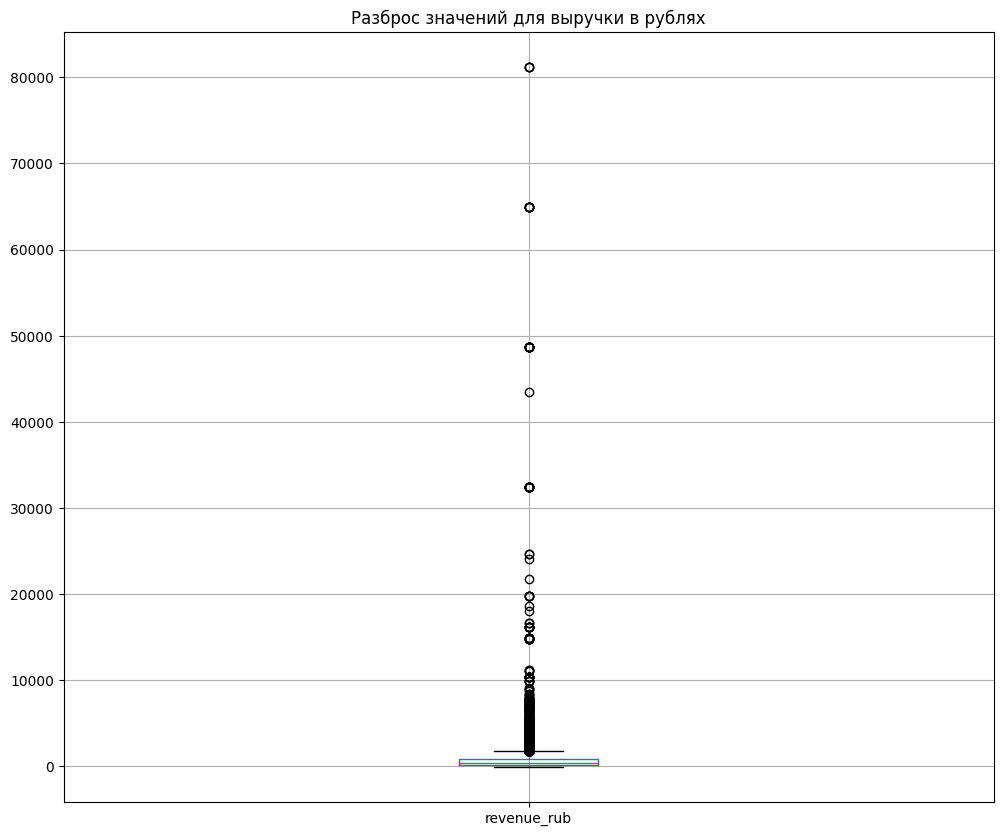

In [29]:
df.boxplot(column='revenue_rub', figsize=(12,10))
plt.title('Разброс значений для выручки в рублях')
plt.show()

В данных поля `revenue_rub` были обнаружены выбросы, поэтому отфильтруем значения по 99 перцентилю.

In [30]:
df = df[df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)]

Построим диаграмму размаха для отфильтрованных данных

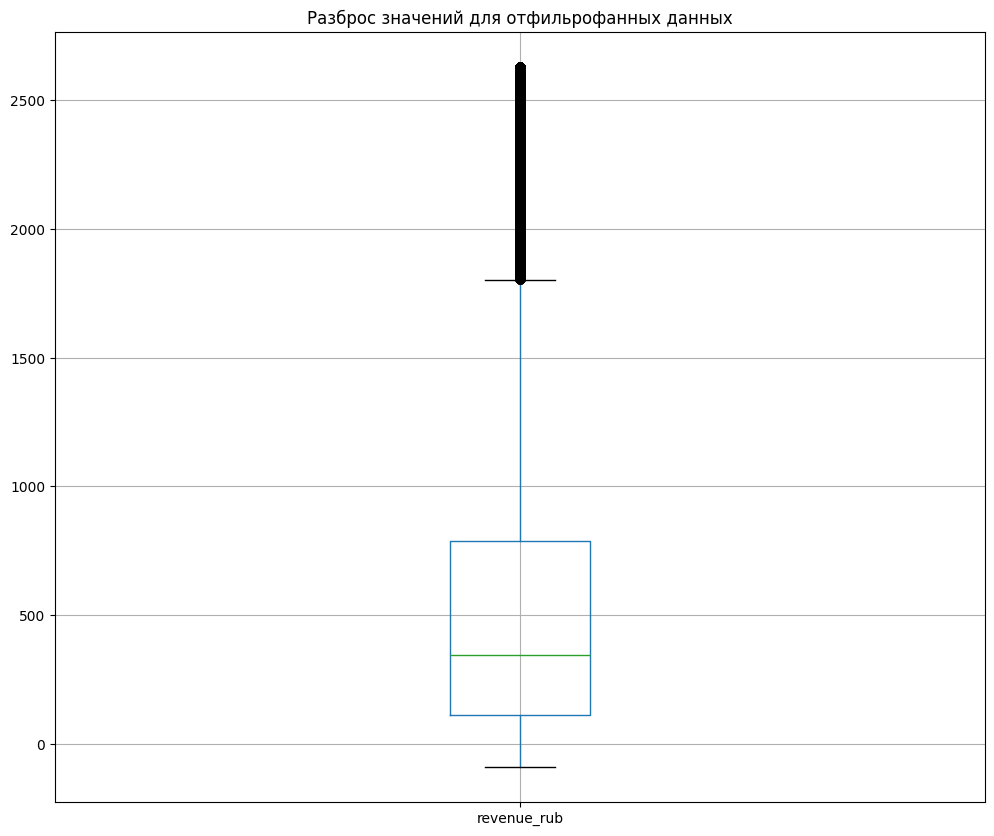

In [31]:
df.boxplot(column='revenue_rub', figsize=(12,10))
plt.title('Разброс значений для отфильрофанных данных')
plt.show()

Как видим на графике, выбросов стало меньше и они стали менее критическими.

Теперь построим диаграмму размаха для столбца `tickets_count`

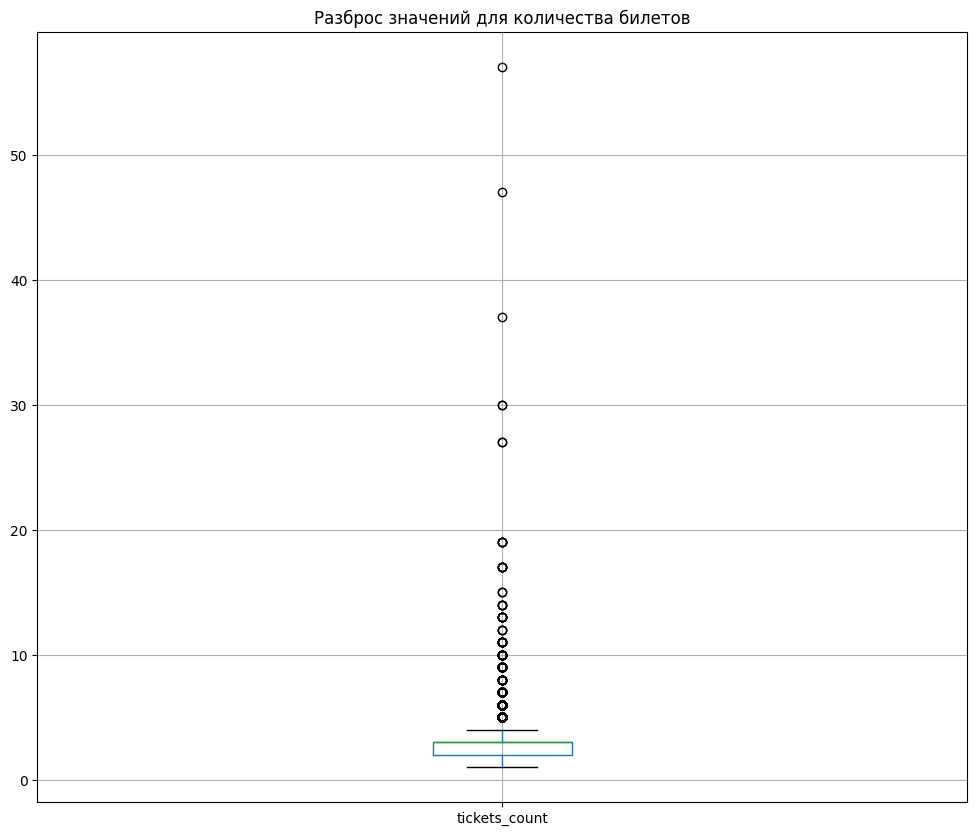

In [32]:
df.boxplot(column='tickets_count', figsize=(12,10))
plt.title('Разброс значений для количества билетов')
plt.show()

Можно заметить выбросы в данных. Такие выбросы могут представлять корпоративные заказы, групповые посещения или перепродавцов.

После предобработки проверим, были ли отфильтрованы данные и в каком объёме.

Количество удаленных строк

In [33]:
tmp.shape[0] - df.shape[0]

2825

Процент удаленных строк

In [34]:
(tmp.shape[0] - df.shape[0]) / tmp.shape[0] * 100

0.9720898383061893

### Промежуточный вывод
Выполненные действия:
- Анализ и обработка пропущенных значений

  
Обнаружены пропуски только в столбце days_since_prev (21,033 записи) - что ожидаемо для первых заказов пользователей. Остальные столбцы не содержат пропусков

- Оптимизация типов данных

  
    `tickets_count` -> int8 (диапазон значений: 1-57)

    `days_since_prev` -> float16 (уменьшена разрядность для экономии памяти)

- Анализ категориальных переменных

   Данные корректны, нормализация не требуется

- Обработка выбросов в числовых данных

`revenue_rub`: Обнаружены значительные выбросы, выполнена фильтрация по 99-му перцентилю

`tickets_count`: Наличие выбросов (заказы до 57 билетов), требующих дополнительного анализа

**Результаты фильтрации:**

Отфильтровано записей: 2,825 строк

Сохранилось записей: 287,786 строк (из исходных 290,611)

Процент отфильтрованных данных: ~0.97%

**Интерпретация выбросов:**

Выбросы в `revenue_rub` и `tickets_count` могут представлять:

Корпоративные заказы

Групповые посещения мероприятий

Ошибки в данных

Деятельность перепродавцов билетов

**Созданные столбцы:**

`revenue_rub` - унифицированная выручка в российских рублях после конвертации из KZT


**Данные подготовлены для дальнейшего анализа:**

- Унифицирована валюта выручки

- Оптимизированы типы данных для экономии памяти

- Удалены экстремальные выбросы, мешающие анализу типичного поведения пользователей

- Сохранена информативность данных для построения профилей пользователей

---

### 3. Создание профиля пользователя

 Построим агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** 

---


Отсортируем данные по `id` пользователя и по времени совершения заказа.

In [35]:
df_sorted = df.sort_values(['user_id', 'order_dt'])

Построим новый датафрейм `user_df`, в него войдут - для каждого пользователя:
- даты первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия;
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

In [36]:
user_df = df_sorted.groupby('user_id').agg(
    first_order_dt = ('order_dt', 'first'),
    last_order_dt = ('order_dt', 'last'),
    first_device_type = ('device_type_canonical', 'first'),
    first_region = ('region_name', 'first'),
    first_service = ('service_name', 'first'),
    first_event_type = ('event_type_main', 'first'),
    total_orders = ('order_id', 'count'),
    avg_revenue_rub = ('revenue_rub', 'mean'),
    avg_tickets = ('tickets_count', 'mean'),
    avg_days_between_order = ('days_since_prev', 'mean')
)

Добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

In [37]:
user_df['is_two'] = user_df['total_orders'] >= 2
user_df['is_five'] = user_df['total_orders'] >= 5

Преобразуем индекс `user_id` в колонку для удобства анализа.

In [38]:
user_df = user_df.reset_index()

Выведем первые 5 строк получившегося датафрейма

In [39]:
user_df.head()

,user_id,first_order_dt,last_order_dt,first_device_type,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets,avg_days_between_order,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.


Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

In [40]:
stats = pd.Series({
    'total_users' : user_df.shape[0],
    'avg_revenue' : user_df['avg_revenue_rub'].mean(),
    'two_orders_user_share' : user_df['is_two'].sum() / user_df.shape[0],
    'five_orders_user_share' : user_df['is_five'].sum() / user_df.shape[0]
    })
stats

total_users               21854.000000
avg_revenue                 544.398051
two_orders_user_share         0.617095
five_orders_user_share        0.290061
dtype: float64

Данные репрезентативны и составляют 21854 пользователя. Большинство пользователей (62%) возвращаются после первого заказа, каждый третий (29%) становится постоянным клиентом с 5+ заказов. Средний чек — 544 рубля.

**Также изучим статистические показатели:**

- По общему числу заказов

In [41]:
user_df['total_orders'].describe()

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10181.000000
Name: total_orders, dtype: float64

- По среднему числу билетов в заказе

In [42]:
user_df['avg_tickets'].describe()

count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
max         11.000000
Name: avg_tickets, dtype: float64

- По среднему количеству дней между покупками

In [43]:
user_df['avg_days_between_order'].describe()

count    13513.000000
mean        15.851275
std         22.306225
min          0.000000
25%          1.000000
50%          8.000000
75%         20.428572
max        148.000000
Name: avg_days_between_order, dtype: float64

### Оценка данных и аномальных значений
**1. Объем данных:**

21,854 пользователя - достаточный объем для анализа

62% пользователей с повторными заказами - репрезентативная выборка

**2. Выявленные аномалии:**
- Количество заказов (total_orders)
  
    Максимум: 10,181 заказ - явная аномалия

    Std: 121.7 - огромное отклонение

- Среднее количество билетов (avg_tickets)
  
    Максимум: 11 билетов - возможная аномалия

    Распределение более стабильное (std: 0.9)

- Дни между заказами (avg_days_between_order)
  
    Максимум: 148 дней - в пределах разумного

    Распределение относительно нормальное

**Действия с данными**

Для `avg_tickets` - оставим как есть:
Максимум 11 билетов может быть реальным (групповые заказы)

Для `avg_days_between_order` - оставим как есть:
148 дней между заказами - реалистичный показатель

Для `total_orders` - отфильтруем по 99-му перцентилю

In [44]:
tmp = user_df
user_df = user_df[user_df['total_orders'] <= user_df['total_orders'].quantile(0.99)]

Количество отфильтрованных строк

In [45]:
tmp.shape[0] - user_df.shape[0]

216

Процент отфильтрованных строк

In [46]:
(tmp.shape[0] - user_df.shape[0]) / tmp.shape[0] * 100

0.9883774137457674

**Изучим статистические показатели для отфильрованного датафрейма:**

- По общему числу заказов

In [47]:
user_df['total_orders'].describe()

count    21638.000000
mean         6.501294
std         14.324031
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_orders, dtype: float64

- По среднему числу билетов в заказе

In [48]:
user_df['avg_tickets'].describe()

count    21638.000000
mean         2.743319
std          0.917486
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets, dtype: float64

- По среднему количеству дней между покупками.

In [49]:
user_df['avg_days_between_order'].describe()

count    13297.000000
mean        16.101315
std         22.399511
min          0.000000
25%          1.333333
50%          8.352942
75%         20.750000
max        148.000000
Name: avg_days_between_order, dtype: float64

**Вывод после фильтрации:**
- Фильтрация успешна:

        Удалено 216 пользователей (1%) с аномальным числом заказов


- Данные стали репрезентативными:

        Среднее количество заказов: 6.5 (было 13.2)

        Медиана: 2 заказа - типичный пользователь совершает 1-2 заказа

        Std снизилось с 121.7 до 14.3 - распределение стало стабильным

Данные готовы для анализа типичного поведения пользователей без влияния экстремальных выбросов

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучим распределение пользователей по признакам и ответим на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


**Сгруппируем пользователей по признакам и подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака:**

- По типу их первого мероприятия

In [50]:
df_groupped_event = user_df.groupby('first_event_type').agg(
    users_count = ('user_id', 'count'),
)
df_groupped_event['users_share'] = df_groupped_event['users_count'] / user_df['user_id'].count()
df_groupped_event = df_groupped_event.sort_values(by='users_count',ascending=False)
df_groupped_event

,users_count,users_share
first_event_type,,
концерты,9560,0.441815
другое,5421,0.250531
театр,4244,0.196136
стендап,1118,0.051668
спорт,795,0.036741
выставки,407,0.018810
ёлки,93,0.004298


Распределение не равномерное. Есть выраженные «точки входа»:

    Концерты - главная точка входа (44% пользователей)

    "Другое" и театр - значимые сегменты (25% и 20%)

Остальные категории существенно меньше

Вывод: Большинство пользователей приходят через концерты.

- По типу устройства, с которого совершена первая покупка

In [51]:
df_groupped_device = user_df.groupby('first_device_type').agg(
    users_count = ('user_id', 'count'),
)
df_groupped_device['users_share'] = df_groupped_device['users_count'] / user_df['user_id'].count()
df_groupped_device = df_groupped_device.sort_values(by='users_count',ascending=False)
df_groupped_device

,users_count,users_share
first_device_type,,
mobile,17904,0.827433
desktop,3734,0.172567


Распределение не равномерное. Есть выраженная «точка входа»:

    Mobile - доминирующее устройство (83% пользователей)

    Desktop - значительно меньше (17%)

Вывод: Подавляющее большинство пользователей совершают первую покупку с мобильных устройств.

- По региону проведения мероприятия из первого заказа

In [52]:
df_groupped_region = user_df.groupby('first_region').agg(
    users_count = ('user_id', 'count'),
)
df_groupped_region['users_share'] = df_groupped_region['users_count'] / user_df['user_id'].count()
df_groupped_region = df_groupped_region.sort_values(by='users_count',ascending=False)
df_groupped_region

,users_count,users_share
first_region,,
Каменевский регион,7084,0.327387
Североярская область,3768,0.174138
Широковская область,1230,0.056844
Озернинский край,673,0.031103
Малиновоярский округ,521,0.024078
...,...,...
Залесский край,2,0.000092
Тихогорская область,2,0.000092
Верхозёрский край,1,0.000046


Распределение не равномерное. Есть выраженные «точки входа»:

    Каменевский регион - главный регион (33% пользователей)

    Североярская область - второй по значимости (17%)

Остальные регионы существенно меньше, многие с единичными пользователями

Вывод: Пользователи сильно сконцентрированы в двух основных регионах.

- По билетному оператору, продавшему билеты на первый заказ

In [53]:
df_groupped_service = user_df.groupby('first_service').agg(
    users_count = ('user_id', 'count'),
)
df_groupped_service['users_share'] = df_groupped_service['users_count'] / user_df['user_id'].count()
df_groupped_service = df_groupped_service.sort_values(by='users_count',ascending=False)
df_groupped_service

,users_count,users_share
first_service,,
Билеты без проблем,5175,0.239163
Мой билет,2973,0.137397
Лови билет!,2822,0.130419
Билеты в руки,2553,0.117987
Облачко,2174,0.100471
Весь в билетах,1289,0.059571
Лучшие билеты,1185,0.054765
Прачечная,573,0.026481
Край билетов,458,0.021166


Распределение не равномерное. Есть выраженные «точки входа»:

    "Билеты без проблем" - лидер (24% пользователей)

    "Мой билет", "Лови билет!", "Билеты в руки" - значимые партнеры (13-14% каждый)

Остальные партнеры существенно меньше, многие с единичными пользователями

Вывод: Пользователи сконцентрированы у нескольких крупных билетных операторов.

---

**Задача 4.1.2.** Проанализируем возвраты пользователей и ответим на вопросы:

    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?
---


**Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа**

- По типу первого мероприятия

In [54]:
df_groupped_event['two_orders_count'] = user_df.groupby('first_event_type')['is_two'].sum()
df_groupped_event['two_orders_share'] = df_groupped_event['two_orders_count'] / df_groupped_event['users_count']
df_groupped_event

,users_count,users_share,two_orders_count,two_orders_share
first_event_type,,,,
концерты,9560,0.441815,5911,0.618305
другое,5421,0.250531,3230,0.595831
театр,4244,0.196136,2692,0.634307
стендап,1118,0.051668,684,0.611807
спорт,795,0.036741,444,0.558491
выставки,407,0.018810,258,0.633907
ёлки,93,0.004298,51,0.548387


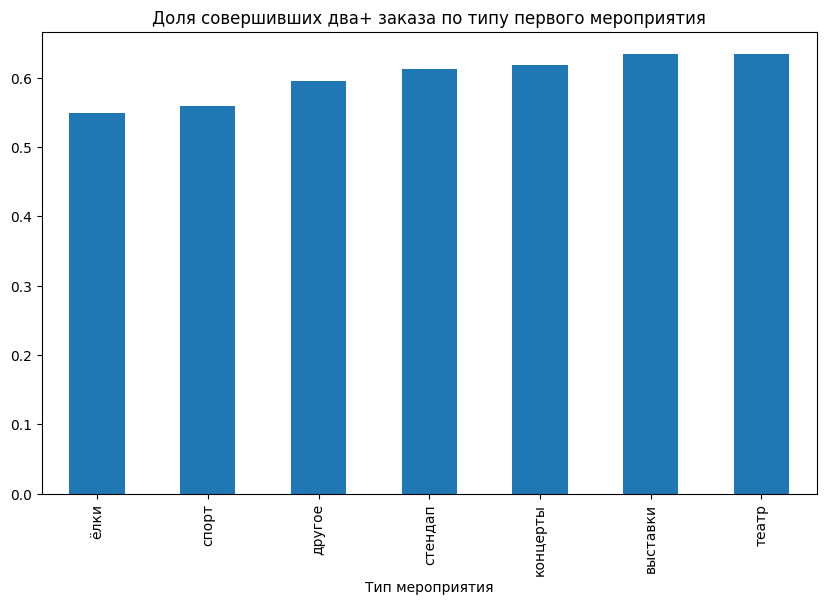

In [55]:
df_groupped_event['two_orders_share'].sort_values().plot(
    kind='bar',
    title='Доля совершивших два+ заказа по типу первого мероприятия',
    figsize=(10,6),
    xlabel = 'Тип мероприятия'
)
plt.show()

Успешные «точки входа» с высокой возвращаемостью:

    Театр (63.4%) и выставки (63.4%) - лидеры по возвращаемости

    Концерты (61.8%) - высокая возвращаемость при большом объеме

    Спорт (55.8%) и ёлки (54.8%) - ниже среднего

Вывод: Театр и выставки - наиболее эффективные точки входа для удержания пользователей.

- По типу устройства

In [56]:
df_groupped_device['two_orders_count'] = user_df.groupby('first_device_type')['is_two'].sum()
df_groupped_device['two_orders_share'] = df_groupped_device['two_orders_count'] / df_groupped_device['users_count']
df_groupped_device

,users_count,users_share,two_orders_count,two_orders_share
first_device_type,,,,
mobile,17904,0.827433,10880,0.607685
desktop,3734,0.172567,2390,0.640064


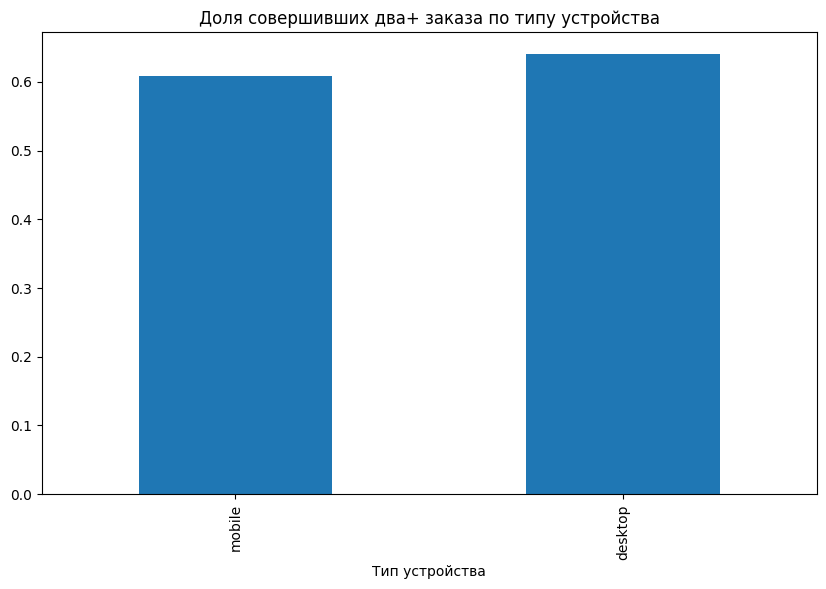

In [57]:
df_groupped_device['two_orders_share'].sort_values().plot(
    kind='bar',
    title='Доля совершивших два+ заказа по типу устройства',
    figsize=(10,6),
    xlabel = 'Тип устройства'
)
plt.show()

Успешные «точки входа» с высокой возвращаемостью:

    Desktop (64.0%) - выше среднего возвращаемости

    Mobile (60.8%) - ниже среднего, но основной объем

Вывод: Пользователи с desktop имеют более высокую лояльность, несмотря на меньшую долю в общем объеме.

- По региону (топ-10)

In [58]:
df_groupped_region['two_orders_count'] = user_df.groupby('first_region')['is_two'].sum()
df_groupped_region['two_orders_share'] = df_groupped_region['two_orders_count'] / df_groupped_region['users_count']
df_groupped_region.head(10)

,users_count,users_share,two_orders_count,two_orders_share
first_region,,,,
Каменевский регион,7084,0.327387,4420,0.623941
Североярская область,3768,0.174138,2405,0.638270
Широковская область,1230,0.056844,796,0.647154
Озернинский край,673,0.031103,371,0.551263
Малиновоярский округ,521,0.024078,290,0.556622
Шанырский регион,499,0.023061,335,0.671343
Травяная область,486,0.022460,298,0.613169
Светополянский округ,458,0.021166,301,0.657205
Речиновская область,439,0.020288,278,0.633257


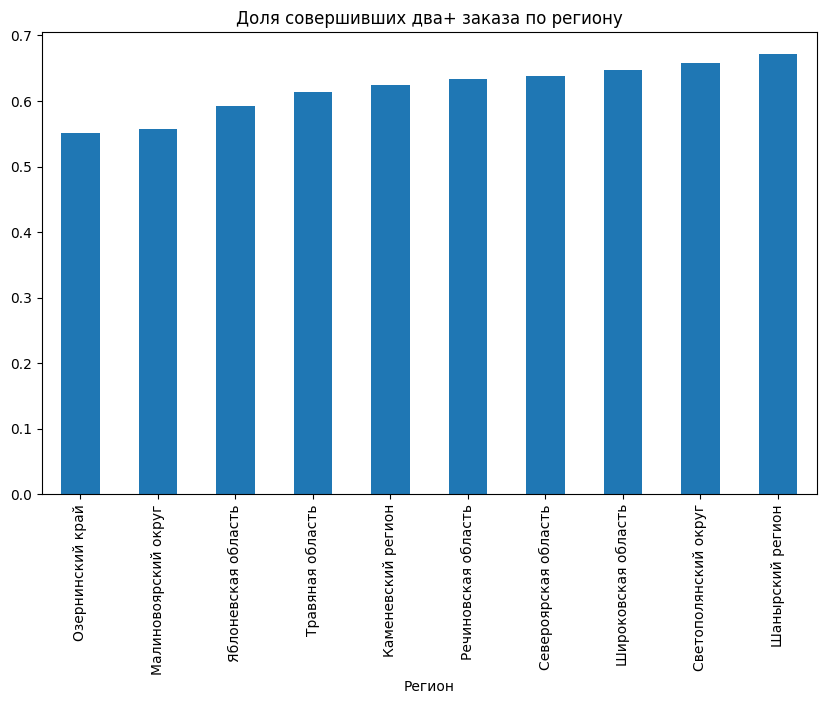

In [59]:
df_groupped_region['two_orders_share'].head(10).sort_values().plot(
    kind='bar',
    title='Доля совершивших два+ заказа по региону',
    figsize=(10,6),
    xlabel = 'Регион'
)
plt.show()

Успешные «точки входа» с высокой возвращаемостью:

    Шанырский регион (67.1%) и Светополянский округ (65.7%) - лидеры по возвращаемости

    Широковская область (64.7%) и Североярская область (63.8%) - высокие показатели

    Каменевский регион (62.4%) - средняя возвращаемость при максимальном объеме

    Озернинский край (55.1%) - низкая возвращаемость

Вывод: Меньшие регионы показывают более высокую лояльность пользователей.

- По билетному оператору, продавшему билеты на первый заказ (топ-10)

In [60]:
df_groupped_service['two_orders_count'] = user_df.groupby('first_service')['is_two'].sum()
df_groupped_service['two_orders_share'] = df_groupped_service['two_orders_count'] / df_groupped_service['users_count']
df_groupped_service.head(10)

,users_count,users_share,two_orders_count,two_orders_share
first_service,,,,
Билеты без проблем,5175,0.239163,3122,0.603285
Мой билет,2973,0.137397,1811,0.609149
Лови билет!,2822,0.130419,1724,0.610914
Билеты в руки,2553,0.117987,1599,0.626322
Облачко,2174,0.100471,1331,0.612236
Весь в билетах,1289,0.059571,812,0.629946
Лучшие билеты,1185,0.054765,726,0.612658
Прачечная,573,0.026481,355,0.619546
Край билетов,458,0.021166,300,0.655022


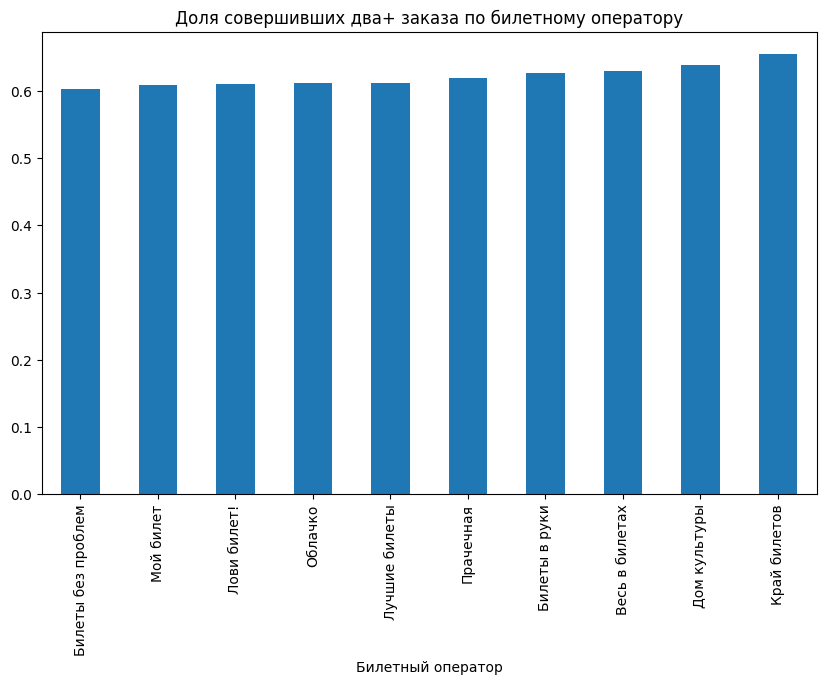

In [61]:
df_groupped_service['two_orders_share'].head(10).sort_values().plot(
    kind='bar',
    title='Доля совершивших два+ заказа по билетному оператору',
    figsize=(10,6),
    xlabel = 'Билетный оператор'
)
plt.show()

Успешные «точки входа» с высокой возвращаемостью:

    "Край билетов" (65.5%) и "Дом культуры" (63.9%) - лидеры по возвращаемости

    "Весь в билетах" (63.0%) и "Билеты в руки" (62.6%) - высокие показатели

    Крупные операторы ("Билеты без проблем", "Мой билет") - средняя возвращаемость 60-61%

Вывод: Меньшие билетные операторы показывают более высокую лояльность пользователей.



---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверим продуктовые гипотезы:




---

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

In [62]:
df_groupped_event = df_groupped_event.reset_index()

In [63]:
df_groupped_event.loc[(df_groupped_event['first_event_type'] == 'спорт') | (df_groupped_event['first_event_type'] == 'концерты'),
    ['first_event_type', 'two_orders_share']]

,first_event_type,two_orders_share
0,концерты,0.618305
4,спорт,0.558491


**Гипотеза не подтвердилась**

    Концерты: 61.8% возвращаемости

    Спорт: 55.8% возвращаемости

Спортивные мероприятия показывают ниже возвращаемость на 6 процентов по сравнению с концертами.

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [64]:
df_groupped_region = df_groupped_region.reset_index()

In [65]:
df_groupped_region[['first_region', 'users_count', 'two_orders_share']].head(10)

,first_region,users_count,two_orders_share
0,Каменевский регион,7084,0.623941
1,Североярская область,3768,0.638270
2,Широковская область,1230,0.647154
3,Озернинский край,673,0.551263
4,Малиновоярский округ,521,0.556622
5,Шанырский регион,499,0.671343
6,Травяная область,486,0.613169
7,Светополянский округ,458,0.657205
8,Речиновская область,439,0.633257
9,Яблоневская область,409,0.591687


**Гипотеза не подтвердилась.**

    Каменевский регион (лидер по пользователям) имеет среднюю возвращаемость 62.4%

    Меньшие регионы (Шанырский, Широковская область) показывают более высокую возвращаемость 64-67%

Вывод: Количество пользователей в регионе не коррелирует с возвращаемостью.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.


- Ответим на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?
---


**Построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):**

- Для пользователей, совершивших один заказ

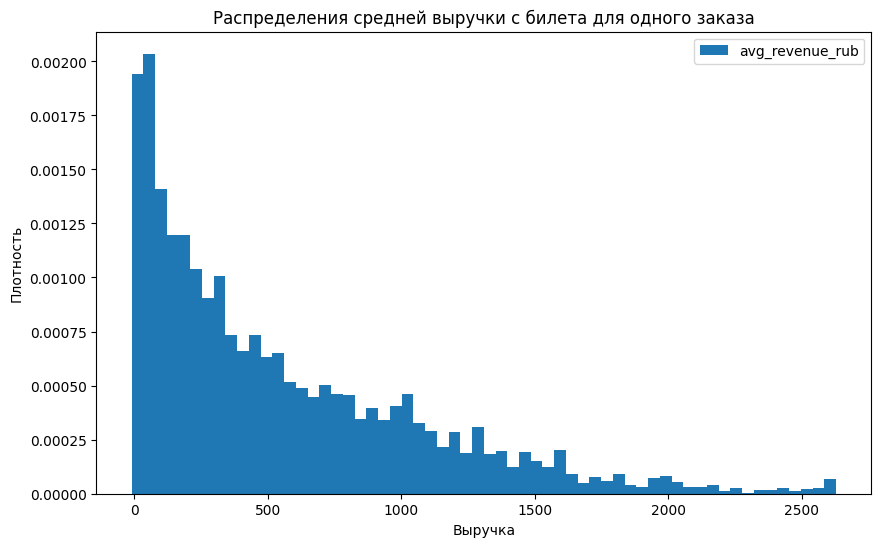

In [66]:
user_df[user_df['is_two'] == False].plot(
    kind = 'hist',
    column = 'avg_revenue_rub',
    bins = 60,
    alpha = 1,
    density = True,
    figsize = (10, 6),
    title = 'Распределения средней выручки с билета для одного заказа',
    xlabel = 'Выручка',
    ylabel = 'Плотность'
)
plt.show()

- Для вернувшихся пользователей, совершивших 2 и более заказа

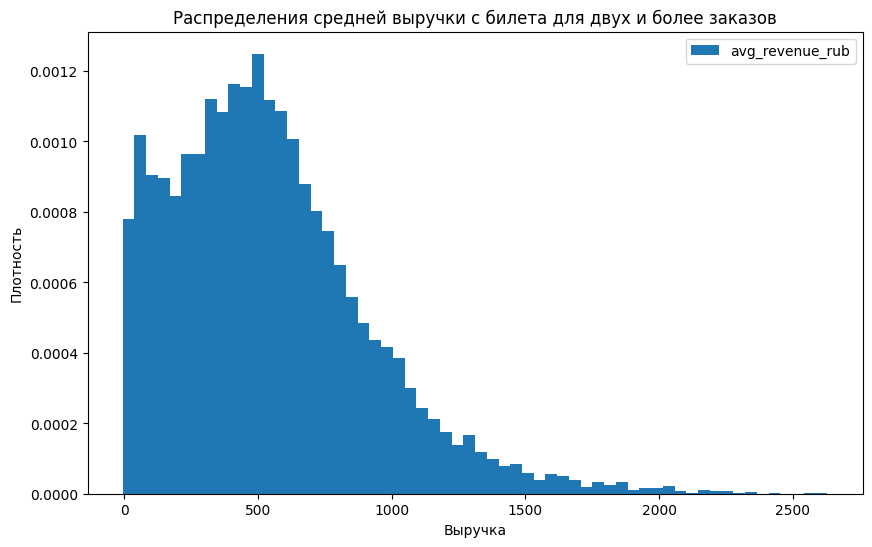

In [67]:
user_df[user_df['is_two'] == True].plot(
    kind = 'hist',
    column = 'avg_revenue_rub',
    bins = 60,
    alpha = 1,
    density = True,
    figsize = (10, 6),
    title = 'Распределения средней выручки с билета для двух и более заказов',
    xlabel = 'Выручка',
    ylabel = 'Плотность'
)
plt.show()

**Диапазоны концентрации пользователей:**

    Обе группы концентрируются в диапазоне 0-2000 рублей

    Пик плотности в районе 200-800 рублей у вернувшихся пользователей и 100 рублей для однократных пользователей

**Различия между группами:**

    Вернувшиеся пользователи (2+ заказов) показывают более равномерное распределение

    У однократных пользователей более выраженный пик в низком ценовом сегменте

    Вернувшиеся пользователи имеют более равномерное распределение по разным ценовым диапазонам

**Ключевое наблюдение:** У вернувшихся пользователей вырастает средняя выручка - они чаще совершают заказы в среднем и премиальном ценовых сегментах, в то время как однократные пользователи преимущественно остаются в бюджетной категории.

**Вывод:** Существует положительная корреляция между лояльностью пользователей и средним чеком - возвращающиеся клиенты демонстрируют не только более стабильное и разнообразное поведение, но и большую готовность к дорогим покупкам.

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершивших 2–4 заказа;
- совершивших 5 и более заказов.

Ответим на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Построим гистограмму по средней выручке для пользователей, совершивших 2-4 заказа

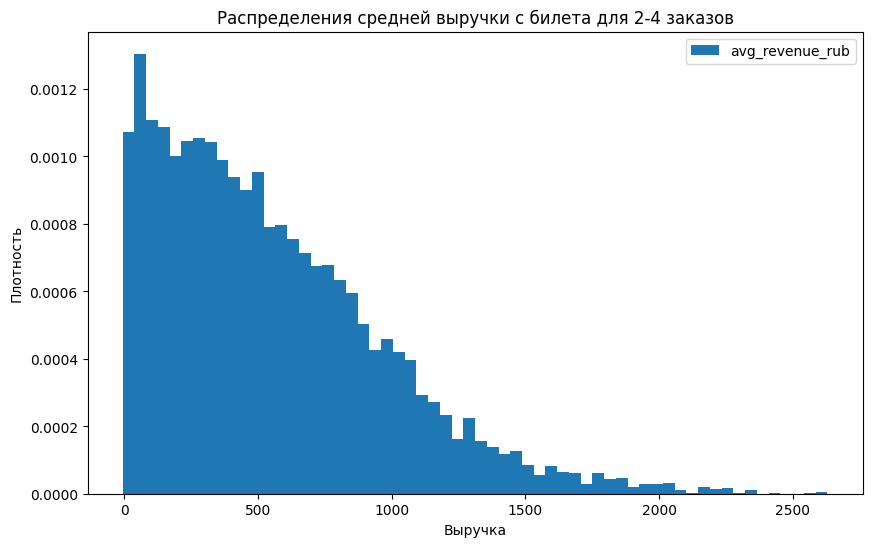

In [68]:
user_df[(user_df['is_two'] == True) & (user_df['is_five'] == False)].plot(
    kind = 'hist',
    column = 'avg_revenue_rub',
    bins = 60,
    alpha = 1,
    density = True,
    figsize = (10, 6),
    title = 'Распределения средней выручки с билета для 2-4 заказов',
    xlabel = 'Выручка',
    ylabel = 'Плотность'
)
plt.show()

Построим гистограмму по средней выручке для пользователей, совершивших 5+ заказов

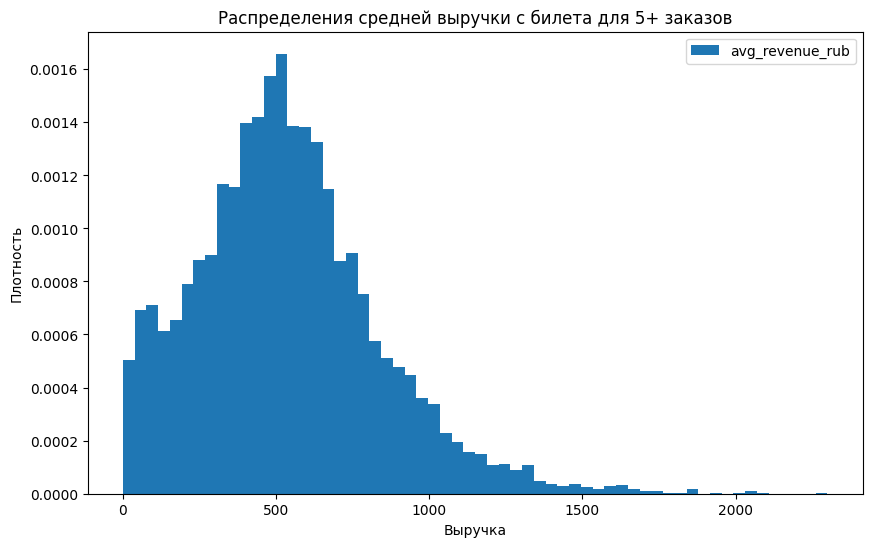

In [69]:
user_df[user_df['is_five'] == True].plot(
    kind = 'hist',
    column = 'avg_revenue_rub',
    bins = 60,
    alpha = 1,
    density = True,
    figsize = (10, 6),
    title = 'Распределения средней выручки с билета для 5+ заказов',
    xlabel = 'Выручка',
    ylabel = 'Плотность'
)
plt.show()

**Существенные различия обнаружены:**

**Распределение по группам:**

    2-4 заказа: Распределение более широкое, с правым хвостом до 2500 рублей

    5+ заказов: Распределение более сконцентрированное, обрезается на 2000 рублей

**Ключевые различия:**

    Пиковая плотность: У группы 5+ заказов пик плотности значительно выше (0.0016 vs 0.0012)

    Ценовой диапазон: Постоянные клиенты (5+) более сконцентрированы в узком ценовом диапазоне

    Разброс значений: Группа 2-4 заказа демонстрирует больший разброс по выручке

**Вывод:**

    Наиболее лояльные пользователи (5+ заказов) демонстрируют более стабильное и предсказуемое ценовое поведение - они концентрируются в определенном ценовом сегменте, в то время как менее активные пользователи (2-4 заказа) имеют более разнообразные паттерны ценового поведения.


**Это может указывать на то, что постоянные клиенты находят оптимальный для себя ценовой диапазон и придерживаются его при повторных покупках.**

---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.



---

- Изучим распределение пользователей по среднему количеству билетов в заказе (`avg_tickets`)

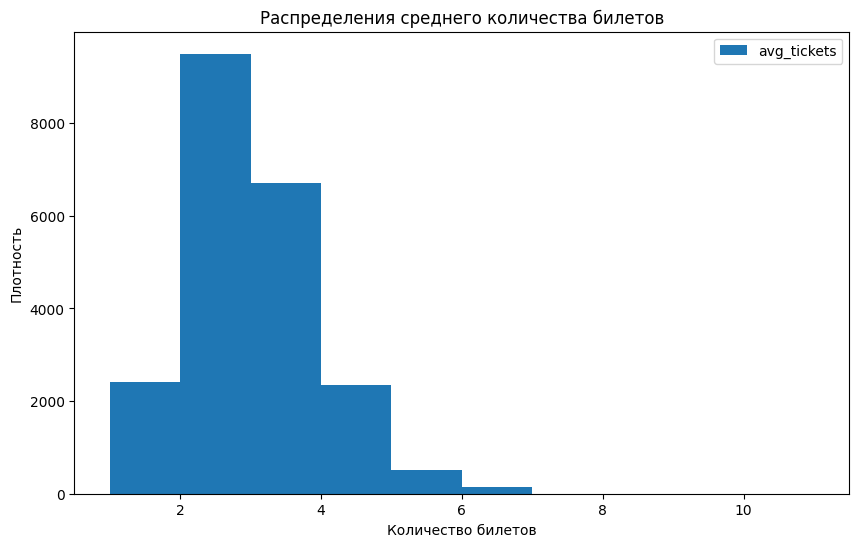

In [70]:
user_df.plot(
    kind = 'hist',
    column = 'avg_tickets',
    bins = 10,
    alpha = 1,
    figsize = (10, 6),
    title = 'Распределения среднего количества билетов',
    xlabel = 'Количество билетов',
    ylabel = 'Плотность'
)
plt.show()

Распределение сильно скошено влево - большинство пользователей покупают в среднем 2-4 билета за заказ.

**Основные наблюдения:**

    Пик распределения приходится на минимальные значения (2-4 билета)

    Количество пользователей резко уменьшается с ростом числа билетов

    Пользователи, покупающие 4+ билета в среднем за заказ, составляют меньшинство

**Вывод:** Типичное поведение - покупка 2-4 билетов, что соответствует индивидуальным или парным посещениям мероприятий

- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответим на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?


Разделим пользователей по сегментам

In [71]:
df_segments = pd.DataFrame({
    'segment': ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов'],
    'users_count': [
        user_df[(user_df['avg_tickets'] >= 1) & (user_df['avg_tickets'] <= 2)]['user_id'].count(),
        user_df[(user_df['avg_tickets'] >= 2) & (user_df['avg_tickets'] <= 3)]['user_id'].count(),
        user_df[(user_df['avg_tickets'] >= 3) & (user_df['avg_tickets'] <= 5)]['user_id'].count(),
        user_df[user_df['avg_tickets'] >= 5]['user_id'].count()
    ],
    'return_users_count': [
        user_df[(user_df['avg_tickets'] >= 1) & (user_df['avg_tickets'] <= 2)]['is_two'].sum(),
        user_df[(user_df['avg_tickets'] >= 2) & (user_df['avg_tickets'] <= 3)]['is_two'].sum(),
        user_df[(user_df['avg_tickets'] >= 3) & (user_df['avg_tickets'] <= 5)]['is_two'].sum(),
        user_df[user_df['avg_tickets'] >= 5]['is_two'].sum()
    ]
})

df_segments['return_share'] = df_segments['return_users_count'] / df_segments['users_count']


Выведем получившийся датафрейм

In [72]:
df_segments

,segment,users_count,return_users_count,return_share
0,1-2 билета,6160,2473,0.401461
1,2-3 билета,13676,8612,0.629716
2,3-5 билетов,9527,4977,0.522410
3,5+ билетов,661,124,0.187595


**Распределение пользователей по сегментам:**

**Распределение не равномерное, сильно сконцентрировано:**

    2-3 билета - крупнейший сегмент

    3-5 билетов - второй по величине 

    1-2 билета - значительный сегмент 

    5+ билетов - очень малая доля 

**Сегменты с аномальной долей повторных покупок:**

    Аномально высокая доля: 2-3 билета (62%) - лидер по возвращаемости

    Аномально низкая доля: 5+ билетов (19%) и 1-2 билета (40%)

**Ключевой вывод:**

Оптимальный сегмент - пользователи, покупающие в среднем 2-3 билета за заказ, показывающие максимальную лояльность. Групповые заказы (5+ билетов) демонстрируют низкую возвращаемость, вероятно, представляя разовые корпоративные или массовые покупки.



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.




---


- По данным даты первого заказа выделим день недели

In [73]:
user_df = user_df.copy()
user_df['day_of_week'] = user_df['first_order_dt'].dt.day_name()

- Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [74]:
groupped_df_day = user_df.groupby('day_of_week').agg(
    user_count = ('user_id', 'count'),
    two_orders_count = ('is_two', 'sum')
)
groupped_df_day['two_orders_share'] = groupped_df_day['two_orders_count'] / groupped_df_day['user_count']

Отсортируем получившийся датафрейм по количеству пользователей

In [75]:
grupped_df_day = groupped_df_day.sort_values(by='user_count', ascending=False)

Выведем получившийся датафрейм

In [76]:
groupped_df_day.sort_values(by='user_count', ascending=False)

,user_count,two_orders_count,two_orders_share
day_of_week,,,
Saturday,3326,2089,0.628082
Friday,3259,1950,0.598343
Tuesday,3176,1966,0.619018
Thursday,3113,1850,0.594282
Wednesday,3057,1901,0.621851
Monday,2930,1847,0.630375
Sunday,2777,1667,0.600288


Визуализируем наш датафрейм

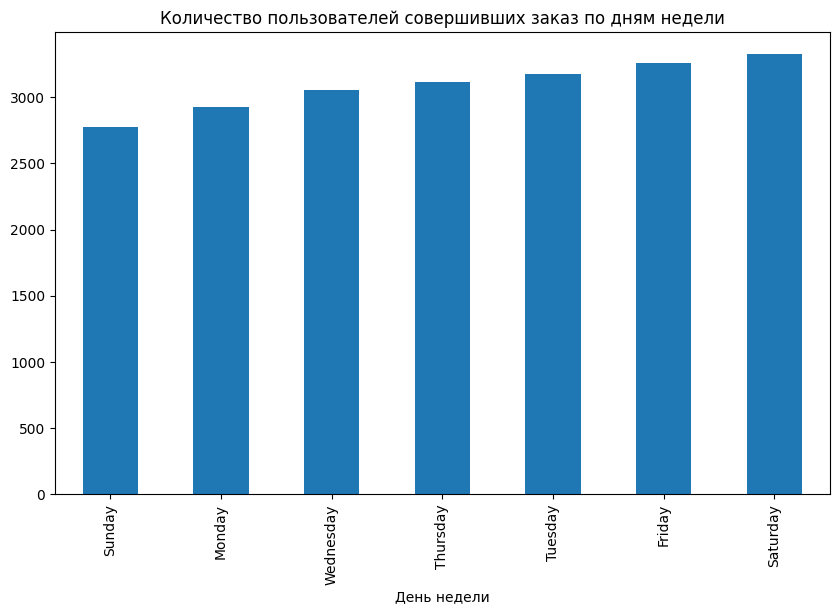

In [77]:
groupped_df_day['user_count'].sort_values().plot(
    kind='bar',
    title='Количество пользователей совершивших заказ по дням недели',
    figsize=(10,6),
    xlabel = 'День недели'
)
plt.show()

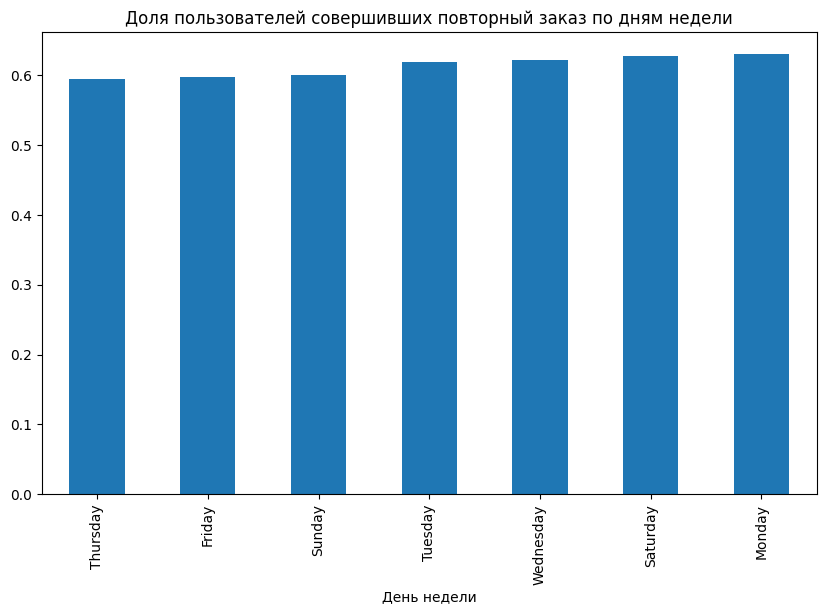

In [78]:
groupped_df_day['two_orders_share'].sort_values().plot(
    kind='bar',
    title='Доля пользователей совершивших повторный заказ по дням недели',
    figsize=(10,6),
    xlabel = 'День недели'
)
plt.show()

- Ответим на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

День недели первой покупки влияет на вероятность возврата клиента.

**Наибольшая возвращаемость:** Понедельник (63.0%) и Суббота (62.8%)

**Наименьшая возвращаемость:** Четверг (59.4%) и Пятница (59.8%)

**Разница:** До 3.6 процентных пунктов между лучшим и худшим днем

**Выводы:**

    Начало недели (понедельник) и выходные (суббота) показывают наибольшую лояльность

    Конец рабочей недели (четверг-пятница) - наименьшая возвращаемость



---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.


---


- Рассчитаем среднее время между заказами для двух групп пользователей:

    - совершивших 2–4 заказа

In [79]:
print(user_df.loc[(user_df['is_two'] == True) & (user_df['is_five'] == False),'avg_days_between_order'].mean())

21.329939


    - совершивших 5 и более заказов

In [80]:
print(user_df.loc[user_df['is_five'] == True,'avg_days_between_order'].mean())

9.900063


Обнаружена сильная обратная зависимость между интервалом между заказами и лояльностью пользователей.

**Ключевые показатели:**

    2-4 заказа: 21.3 дня между заказами

    5+ заказов: 9.9 дня между заказами

**Интерпретация:**

    Более лояльные пользователи (5+ заказов) возвращаются в 2 раза чаще - каждые 10 дней

    Менее активные пользователи (2-4 заказа) делают повторные покупки в среднем через 3 недели

    Короткие интервалы между заказами прямо коррелируют с высокой лояльностью

**Вывод:**

    Частота взаимодействия - ключевой показатель удержания. Пользователи, которые возвращаются в течение 10 дней, с большей вероятностью становятся постоянными клиентами.



---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведем корреляционный анализ:



---

- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). Параметр `interval_cols` будем использовать для определения интервальных данных.

In [81]:
corr_columns = ['first_device_type',
                'first_region',
                'first_service',
                'first_event_type',
                'total_orders',
                'avg_revenue_rub',
                'avg_tickets',
                'avg_days_between_order',
                'is_two',
                'is_five',
                'day_of_week'
               ]
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between_order']
corr_matrix = user_df[corr_columns].phik_matrix(interval_cols=interval_cols)
corr_matrix['total_orders']

first_device_type         0.021401
first_region              0.111268
first_service             0.032209
first_event_type          0.027146
total_orders              1.000000
avg_revenue_rub           0.219482
avg_tickets               0.225904
avg_days_between_order    0.284542
is_two                    0.309085
is_five                   0.615266
day_of_week               0.060837
Name: total_orders, dtype: float64

- Визуализируем результат корреляции с помощью тепловой карты.

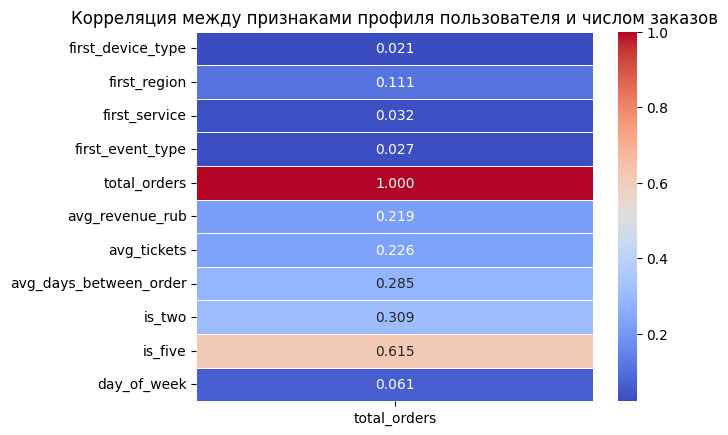

In [82]:
sns.heatmap(corr_matrix['total_orders'].to_frame(), annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция между признаками профиля пользователя и числом заказов')
plt.show()

- Также выделим сегменты пользователей по полю `total_orders` и  повторим корреляционный анализ. Выделим такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.

In [83]:
user_df.loc[user_df['total_orders'] == 1,'order_segment'] = '1 order'
user_df.loc[(user_df['total_orders'] >= 2) & (user_df['total_orders'] <= 4),'order_segment'] = '2-4 order'
user_df.loc[user_df['total_orders'] >= 5,'order_segment'] = '5+ order'

In [84]:
corr_columns = ['first_device_type',
                'first_region',
                'first_service',
                'first_event_type',
                'order_segment',
                'avg_revenue_rub',
                'avg_tickets',
                'avg_days_between_order',
                'is_two',
                'is_five',
                'day_of_week'
               ]
interval_cols = ['avg_revenue_rub', 'avg_tickets', 'avg_days_between_order']
corr_matrix = user_df[corr_columns].phik_matrix(interval_cols=interval_cols)
corr_matrix['order_segment']

first_device_type         0.019131
first_region              0.126138
first_service             0.079633
first_event_type          0.038267
order_segment             1.000000
avg_revenue_rub           0.326101
avg_tickets               0.383400
avg_days_between_order    0.391752
is_two                    1.000000
is_five                   1.000000
day_of_week               0.034269
Name: order_segment, dtype: float64

- Визуализируем результат корреляции с помощью тепловой карты.

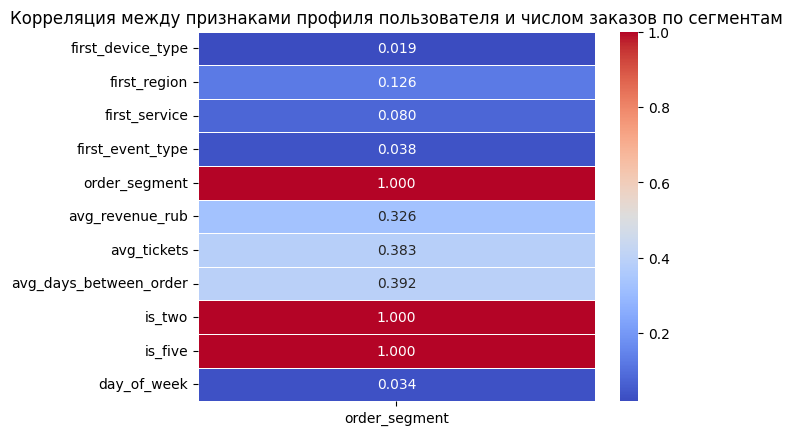

In [85]:
sns.heatmap(corr_matrix['order_segment'].to_frame(), annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция между признаками профиля пользователя и числом заказов по сегментам')
plt.show()

- Ответим на вопрос: какие признаки наиболее связаны с количеством заказов?

**Вывод:**

    Поведенческие метрики (частота покупок, средний чек, количество билетов) сильно влияют на лояльность

    Демографические признаки (регион, тип устройства) слабо связаны с количеством заказов

    Бинарные признаки возврата (is_two, is_five) ожидаемо сильно коррелируют

    Короткие интервалы между заказами - важный индикатор лояльности

### 5. Общий вывод и рекомендации



#### Подготовка данных
- Проанализировано **21,638 пользователей** и **287,786 заказов**
- Выручка унифицирована в российские рубли (конвертация KZT -> RUB)
- Отфильтрованы выбросы по 99-му перцентилю (удалено 0.97% данных)
- Оптимизированы типы данных для ключевых показателей

#### Ключевые метрики пользователей
- **62% пользователей** возвращаются после первого заказа
- **29% пользователей** становятся постоянными клиентами (5+ заказов)
- Средний чек: **544 рубля**

#### Факторы возвращаемости пользователей

##### Признаки первого заказа
- **Высокая возвращаемость:** театр (63.4%), выставки (63.4%)
- **Низкая возвращаемость:** спорт (55.8%), ёлки (54.8%)
- **Desktop-пользователи** более лояльны (64%) vs mobile (61%)

##### Влияние выручки и состава заказа
- **Вернувшиеся пользователи** имеют более разнообразное ценовое поведение
- **Средняя выручка растет** с увеличением лояльности
- **Оптимальный сегмент:** 2-3 билета за заказ (54% возвращаемости)

##### Временные характеристики
- **Лучшие дни:** понедельник (63%), суббота (62.8%)
- **Ключевой показатель:** интервал между заказами
  - 5+ заказов: **9.9 дней** между покупками
  - 2-4 заказа: **21.3 дня** между покупками

#### Корреляционный анализ
**Наиболее влиятельные факторы на количество заказов:**
1. Интервал между заказами (0.392)
2. Среднее количество билетов (0.383)
3. Средняя выручка (0.326)

#### Рекомендации для команды маркетинга

##### Приоритетные сегменты для удержания
1. **Пользователи с 2-3 билетами** в заказе - максимальная лояльность
2. **Desktop-аудитория** - более высокая возвращаемость
3. **Посетители театров и выставок** - высокий потенциал повторных покупок

##### Оптимизация маркетинговой стратегии
- Сместить акценты на **понедельник и субботу**
- Внедрить рассылки для пользователей с **интервалом 10+ дней** между заказами
- Разработать программу лояльности для **бюджетного сегмента** (1-2 заказа)

##### Мониторинг ключевых метрик
- Отслеживать **интервалы между заказами** как основной индикатор лояльности
- Контролировать **среднее количество билетов** в заказе
- Анализировать **динамику среднего чека** по сегментам

**Итог:** Фокус на поведенческих метриках (частота покупок, средний чек) и оптимизация времени коммуникации позволят значительно повысить удержание клиентов и эффективность маркетингового бюджета.

### 6. Финализация проекта и публикация в Git



**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/arr3sling/Project_sprint2